In [1]:
# ONLY RUN THIS ONCE
import os
os.chdir("..")

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.cm import get_cmap
from pathlib import Path
from utils import *
from plotting import *

DATA_PATH = Path("C:/Users/Zahra/Box/UofT-UIC-/second run in UIC/IDOT-20260423T161905Z-3-001/IDOT/W065_08-17-2025/W065_08-17-2025")
IMAGE_PATH = DATA_PATH / "images"

detections_df = get_detections_df(DATA_PATH)
image_file_paths, image_file_names, image_timestamp_ns = get_image_file_names(IMAGE_PATH)

In [9]:
test_image = 1755389403442999378
test_file = IMAGE_PATH / "1755389403442999378-snapshot.jpg"

In [10]:
CLASS_COLORS = {}

def _get_color(cls):
    if cls not in CLASS_COLORS:
        CLASS_COLORS[cls] = get_cmap("tab10")(len(CLASS_COLORS) % 10)
    return CLASS_COLORS[cls]

def plot_bboxes(df, ax, label=True):
    """Overlay bounding boxes from df onto an existing ax (e.g. from plot_image)."""
    for _, row in df.iterrows():
        color = _get_color(row["class"])
        rect = patches.Rectangle(
            (row.x_min, row.y_min),
            row.x_max - row.x_min,
            row.y_max - row.y_min,
            linewidth=1.5, edgecolor=color, facecolor="none"
        )
        ax.add_patch(rect)
        if label:
            ax.text(
                row.x_min, row.y_min - 4,
                f"{row['class']} {row.confidence:.2f}",
                fontsize=7, color="white", fontweight="bold",
                bbox=dict(facecolor=color, edgecolor="none", pad=1)
            )
    return ax

In [11]:
# get indices of timestamps
n_timestamps = 2
all_timestamps_ns = sorted(detections_df.timestamps_ns.unique())
i = all_timestamps_ns.index(test_image)
analysis_timestamps_ns = all_timestamps_ns[i:i+n_timestamps]

# filter detections
analysis_detections_df = detections_df[detections_df["timestamps_ns"].isin([
    int(timestamp_ns) for timestamp_ns in analysis_timestamps_ns
])]


analysis_detections_df["t_sec"] =(analysis_detections_df["timestamps_ns"] - analysis_detections_df["timestamps_ns"].min())/1e9
analysis_detections_df = analysis_detections_df[analysis_detections_df["class"].isin(["car", "person", "bus", "truck"])]

C:\Users\Zahra\AppData\Local\Temp\ipykernel_31920\115022697.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  analysis_detections_df["t_sec"] =(analysis_detections_df["timestamps_ns"] - analysis_detections_df["timestamps_ns"].min())/1e9


ValueError: 'c' argument must be a color, a sequence of colors, or a sequence of numbers, not array(['car', 'car', 'car', 'person', 'car', 'car', 'person', 'car',
       'car', 'bus', 'car', 'car', 'car', 'car', 'car', 'car', 'person',
       'car', 'truck', 'car', 'car', 'car', 'car', 'car', 'car', 'car',
       'car', 'car', 'car', 'person', 'car', 'person', 'car', 'car',
       'car', 'car', 'car', 'car', 'car', 'car', 'car', 'bus', 'bus',
       'car', 'car', 'car', 'car', 'car', 'car', 'person', 'car',
       'person', 'car'], dtype=object)

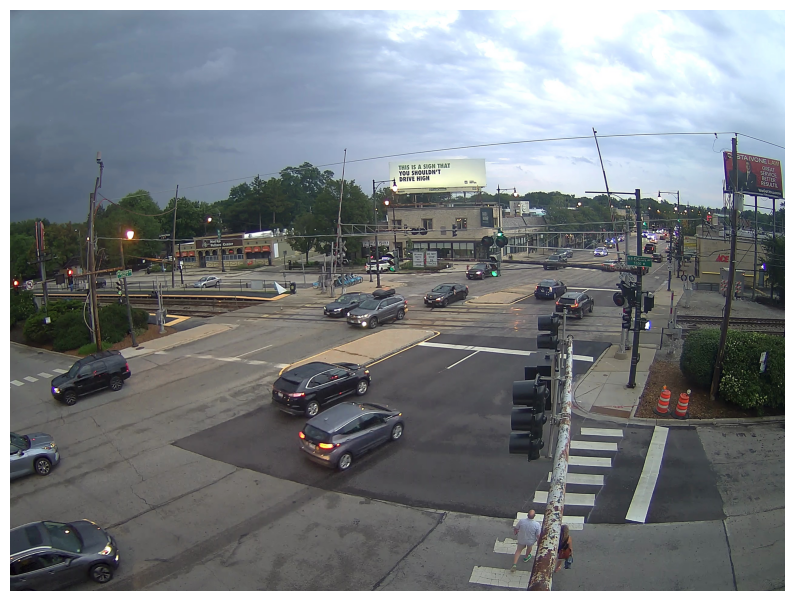

In [12]:
from scipy.optimize import linear_sum_assignment

next_id = 0
active_tracks = {}  # track_id -> {cx, cy, age}
MAX_DIST = 1500     # pixels — max centroid distance to match
MAX_AGE  = 1      # frames before track is killed

analysis_detections_df["cx"] = (analysis_detections_df.x_min + analysis_detections_df.x_max) / 2
analysis_detections_df["cy"] = (analysis_detections_df.y_min + analysis_detections_df.y_max) / 2
analysis_detections_df["track_id"] = -1

for ts, group in analysis_detections_df.groupby("timestamps_ns"):
    idxs = group.index.tolist()
    dets_cx = group["cx"].values
    dets_cy = group["cy"].values
    det_cls  = group["class"].values

    if not active_tracks:
        # cold start — assign new IDs to everything
        for i, idx in enumerate(idxs):
            analysis_detections_df.at[idx, "track_id"] = next_id
            active_tracks[next_id] = {"cx": dets_cx[i], "cy": dets_cy[i],
                                       "cls": det_cls[i], "age": 0}
            next_id += 1
        continue

    # Build cost matrix: detections (rows) x active tracks (cols)
    tids  = list(active_tracks.keys())
    costs = np.full((len(idxs), len(tids)), 1e6)

    for i in range(len(idxs)):
        for j, tid in enumerate(tids):
            if active_tracks[tid]["cls"] != det_cls[i]:
                continue  # never match across classes
            dx = dets_cx[i] - active_tracks[tid]["cx"]
            dy = dets_cy[i] - active_tracks[tid]["cy"]
            costs[i, j] = np.sqrt(dx**2 + dy**2)

    # Hungarian algorithm — optimal assignment
    row_ind, col_ind = linear_sum_assignment(costs)

    matched_dets  = set()
    matched_tracks = set()

    for r, c in zip(row_ind, col_ind):
        if costs[r, c] > MAX_DIST:
            continue  # too far, don't match
        tid = tids[c]
        idx = idxs[r]
        analysis_detections_df.at[idx, "track_id"] = tid
        active_tracks[tid]["cx"]  = dets_cx[r]
        active_tracks[tid]["cy"]  = dets_cy[r]
        active_tracks[tid]["age"] = 0
        matched_dets.add(r)
        matched_tracks.add(tid)

    # Unmatched detections → new tracks
    for i, idx in enumerate(idxs):
        if i not in matched_dets:
            analysis_detections_df.at[idx, "track_id"] = next_id
            active_tracks[next_id] = {"cx": dets_cx[i], "cy": dets_cy[i],
                                       "cls": det_cls[i], "age": 0}
            next_id += 1

    # Age out unmatched tracks
    for tid in list(active_tracks):
        if tid not in matched_tracks:
            active_tracks[tid]["age"] += 1
            if active_tracks[tid]["age"] > MAX_AGE:
                del active_tracks[tid]


plotting_df = analysis_detections_df[analysis_detections_df.timestamps_ns.isin(
    analysis_timestamps_ns[0:]
)]

plotting_df2 = analysis_detections_df[analysis_detections_df.timestamps_ns.isin(
    analysis_timestamps_ns[0:1]
)]

fig, ax = plot_image(test_file)

plotting_df.plot(
    x="cx", y="cy", ax=ax, kind="scatter", c="class", s=8
)

for tid, group in plotting_df[plotting_df["track_id"] > 0].groupby("track_id"):
    cls = group["class"].iloc[0]
    ax.plot(group["cx"], group["cy"], marker="o", markersize=2, label=f"{cls} #{tid}")
    ax.annotate(str(tid), (group["cx"].iloc[-1], group["cy"].iloc[-1]), fontsize=7)


# plot_bboxes(plotting_df2, ax=ax)

plt.show()